# Induced-EQ Forecasting: Multi-Model Background Comparison

Compare background-induced components across multiple checkpoints on the same sequence and forecast window.
Reference workflow adapted from the single-model forecasting notebook.

## 1) Setup

In [2]:
import os
import sys
import functools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing 'src' directory.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src
import src.catalogs as catalogs
import src.utils.catalog_tests as catalog_tests
from src.models.tpp import etas, etas_zhuang, recurrent
from src.train.config_setup import load_and_prepare_model
from src.utils.forecast_eval import (
    apply_publication_style,
    evaluate_sliding_window_forecast_plots,
    save_pub_figure,
    style_current_figure,
    )
from src.utils.tpp_experiments import load_tpp_catalog, sample_tpp_forecasts
from src.utils.utils import set_seed
import src.utils.viz_sequences as vis

apply_publication_style()

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
set_seed(0)
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DEVICE: {DEVICE}')

PROJECT_ROOT: /root/autodl-tmp/em_eqf
DEVICE: cuda:0


## 2) Multi-Model Configuration

In [3]:
# Multi-model checkpoint configuration.
MODEL_SPECS = [
        {
        'name': 'conv (ETAS)',
        'checkpoint_dir': 'checkpoints/etas_20260407-122517',
        'checkpoint_file': 'best_model_1.pth',
        'use_torch_compile': False,
        'model_mm': 6.5,
        'dataset': 'st1'
      },
      {
        'name': 'mamba (ETAS)',
        'checkpoint_dir': 'checkpoints/etas_20260330-142641',
        'checkpoint_file': 'best_model_1.pth',
        'use_torch_compile': False,
        'model_mm': 6.5,
        'dataset': 'st1'
      },
    # {
    #     'name': 'conv (RECAST)',
    #     'checkpoint_dir': 'checkpoints/rtpp_20260407-130706',
    #     'checkpoint_file': 'best_model_1.pth',
    #     'use_torch_compile': False,
    #     'model_mm': 6.5,
    #     'dataset': 'st1'
    # },
    #   {
    #     'name': 'mamba (RECAST)',
    #     'checkpoint_dir': 'checkpoints/rtpp_20260403-202405',
    #     'checkpoint_file': 'best_model_1.pth',
    #     'use_torch_compile': False,
    #     'model_mm': 6.5,
    #     'dataset': 'st1'
    # },
    #  {
    #     'name': 'mamba (ETAS)',
    #     'checkpoint_dir': 'checkpoints/etas_20260330-231612',
    #     'checkpoint_file': 'best_model_1.pth',
    #     'use_torch_compile': False,
    #     'model_mm': 6.5,
    #     'dataset': 'PNR_1z'
    #   },
    #     {
    #     'name': 'mamba (RECAST)',
    #     'checkpoint_dir': 'checkpoints/rtpp_20260402-160131',
    #     'checkpoint_file': 'best_model_1.pth',
    #     'use_torch_compile': False,
    #     'model_mm': 6.5,
    #     'dataset': 'PNR_1z'
    #   },
]

PRIMARY_MODEL_NAME = MODEL_SPECS[0]['name']
SEQUENCE_IDX = 0


# Optional forecast sampling settings used by later sections.
NUM_SAMPLES = 1000
SAMPLES_PER_BATCH = 1000

COMPARE_OUTPUT_DIR = PROJECT_ROOT / 'notebooks' / 'figs' / 'bg_cmp'
COMPARE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Configured models:')
for spec in MODEL_SPECS:
    ckpt_path = PROJECT_ROOT / spec['checkpoint_dir'] / spec.get('checkpoint_file', 'best_model_1.pth')
    print(f"  - {spec['name']}: {ckpt_path}")
print(f'PRIMARY_MODEL_NAME: {PRIMARY_MODEL_NAME}')
print(f'COMPARE_OUTPUT_DIR: {COMPARE_OUTPUT_DIR}')

Configured models:
  - conv (ETAS): /root/autodl-tmp/em_eqf/checkpoints/etas_20260407-122517/best_model_1.pth
  - mamba (ETAS): /root/autodl-tmp/em_eqf/checkpoints/etas_20260330-142641/best_model_1.pth
PRIMARY_MODEL_NAME: conv (ETAS)
COMPARE_OUTPUT_DIR: /root/autodl-tmp/em_eqf/notebooks/figs/bg_cmp


## 3) Load Models and Catalog

In [4]:
from src.utils.runtime_utils import unwrap_compiled_model

model_registry = {}
for spec in MODEL_SPECS:
    name = str(spec['name'])
    if name in model_registry:
        raise ValueError(f'Duplicate model name found: {name}')

    checkpoint_path = PROJECT_ROOT / spec['checkpoint_dir'] / spec.get('checkpoint_file', 'best_model_1.pth')
    if not checkpoint_path.exists():
        raise FileNotFoundError(f'Checkpoint not found for {name}: {checkpoint_path}')

    model_i, args_i = load_and_prepare_model(
        checkpoint_path=checkpoint_path,
        device=DEVICE,
        compile=bool(spec.get('use_torch_compile', False)),
    )
    model_i = unwrap_compiled_model(model_i)

    mm_value = spec.get('model_mm', None)
    if mm_value is not None and hasattr(model_i, 'M_m'):
        model_i.M_m = torch.tensor(float(mm_value), device=DEVICE)

    model_registry[name] = {
        'model': model_i,
        'args': args_i,
        'checkpoint_path': checkpoint_path,
    }

    print(f'[{name}] loaded from: {checkpoint_path}')
    if getattr(model_i, 'bg_model', None) is not None and hasattr(model_i.bg_model, '_scale'):
        print(f'[{name}] background scale: {float(model_i.bg_model._scale.detach().cpu().item()):.6f}')

if PRIMARY_MODEL_NAME not in model_registry:
    raise KeyError(f'PRIMARY_MODEL_NAME not found in MODEL_SPECS: {PRIMARY_MODEL_NAME}')

model = model_registry[PRIMARY_MODEL_NAME]['model']
args = model_registry[PRIMARY_MODEL_NAME]['args']
CHECKPOINT_PATH = model_registry[PRIMARY_MODEL_NAME]['checkpoint_path']
CHECKPOINT_DIR = CHECKPOINT_PATH.parent

print(f'Using primary model: {PRIMARY_MODEL_NAME}')
print(f'PRIMARY CHECKPOINT_DIR: {CHECKPOINT_DIR}')

[conv (ETAS)] loaded from: /root/autodl-tmp/em_eqf/checkpoints/etas_20260407-122517/best_model_1.pth
[conv (ETAS)] background scale: 326.942871
[mamba (ETAS)] loaded from: /root/autodl-tmp/em_eqf/checkpoints/etas_20260330-142641/best_model_1.pth
[mamba (ETAS)] background scale: 993.483948
Using primary model: conv (ETAS)
PRIMARY CHECKPOINT_DIR: /root/autodl-tmp/em_eqf/checkpoints/etas_20260407-122517


Using catalog registry name: St1-2018-Standard


/root/autodl-tmp/em_eqf/src/data/sequence.py:345: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

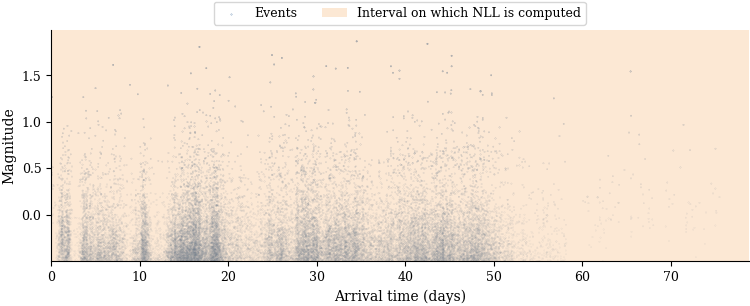

In [5]:
dataset_by_model = {name: rec['args'].dataset for name, rec in model_registry.items()}
if len(set(dataset_by_model.values())) > 1:
    print('Warning: models reference different datasets in checkpoints:')
    for name, dataset_name in dataset_by_model.items():
        print(f'  - {name}: {dataset_name}')

catalog_cfg = getattr(args, 'catalog_cfg', {})
catalog_ds, registry_name, catalog_init_kwargs = load_tpp_catalog(
    args.dataset,
    base_dir=PROJECT_ROOT / 'data' / args.dataset,
    catalog_cfg=catalog_cfg,
)
print(f'Using catalog registry name: {registry_name}')

metadata = catalog_ds.metadata
if  hasattr(metadata, 'start_ts') and hasattr(metadata, 'val_start_ts') and hasattr(metadata, 'test_start_ts') and hasattr(metadata, 'freq'):
    start_ts = pd.to_datetime(metadata['start_ts'])
    val_start_ts = pd.to_datetime(metadata['val_start_ts'])
    test_start_ts = pd.to_datetime(metadata['test_start_ts'])
    freq_td = pd.to_timedelta(metadata['freq'])

    print(f'Primary Model: {args.model} | Dataset: {args.dataset}')
    print(f'train end index: {(val_start_ts - start_ts) / freq_td}')
    print(f'val end index: {(test_start_ts - start_ts) / freq_td}')

full_seq = catalog_ds.full_sequence
sequences = catalog_ds.sequences if hasattr(catalog_ds, 'sequences') else [full_seq]

vis.visualize_sequence(full_seq, show_nll=True)

In [6]:
for name, rec in model_registry.items():
    model_i = rec['model']
    if hasattr(model_i, 'effective_branching_ratio'):
        print(f'[{name}] effective_branching_ratio:{ model_i.effective_branching_ratio(t_max=10)}')
       

[conv (ETAS)] effective_branching_ratio:0.9481297508779453
[mamba (ETAS)] effective_branching_ratio:0.91647488986498


In [7]:
# for name, rec in model_registry.items():
#     if getattr(rec['model'], 'bg_model', None) is not None:
#         rec['model'].bg_model.stochastic_eval = False

In [8]:
catalog_ds.metadata

{'name': 'St1-2018',
 'freq': '1D',
 'freq_min': 1,
 'mag_roundoff_error': 0.01,
 'mag_completeness': -0.5,
 'start_ts': Timestamp('2018-06-04 05:27:26.351000'),
 'end_ts': Timestamp('2018-08-21 23:59:59'),
 'train_start_ts': Timestamp('2018-06-04 05:27:26.351000'),
 'val_start_ts': Timestamp('2018-07-14 00:00:00'),
 'test_start_ts': Timestamp('2018-07-20 00:00:00'),
 'start_t': 0.0,
 'end_t': 78.77260010416667,
 'train_start_t': 0.0,
 'val_start_t': 39.77261167824074,
 'test_start_t': 45.77261167824074,
 'inj_fill_policy': 'upsample_ffill',
 'is_upsample': True}

## 4) Batch and Multi-Model Background Diagnostics

In [9]:
def sequence_to_batch(seq, device):
    batch = src.data.Batch.from_list([seq])
    return batch.to(device)

seq = sequences[SEQUENCE_IDX]
batch = sequence_to_batch(seq, DEVICE)
print(f'SEQUENCE_IDX: {SEQUENCE_IDX} | seq length: {len(seq)}')

SEQUENCE_IDX: 0 | seq length: 30252


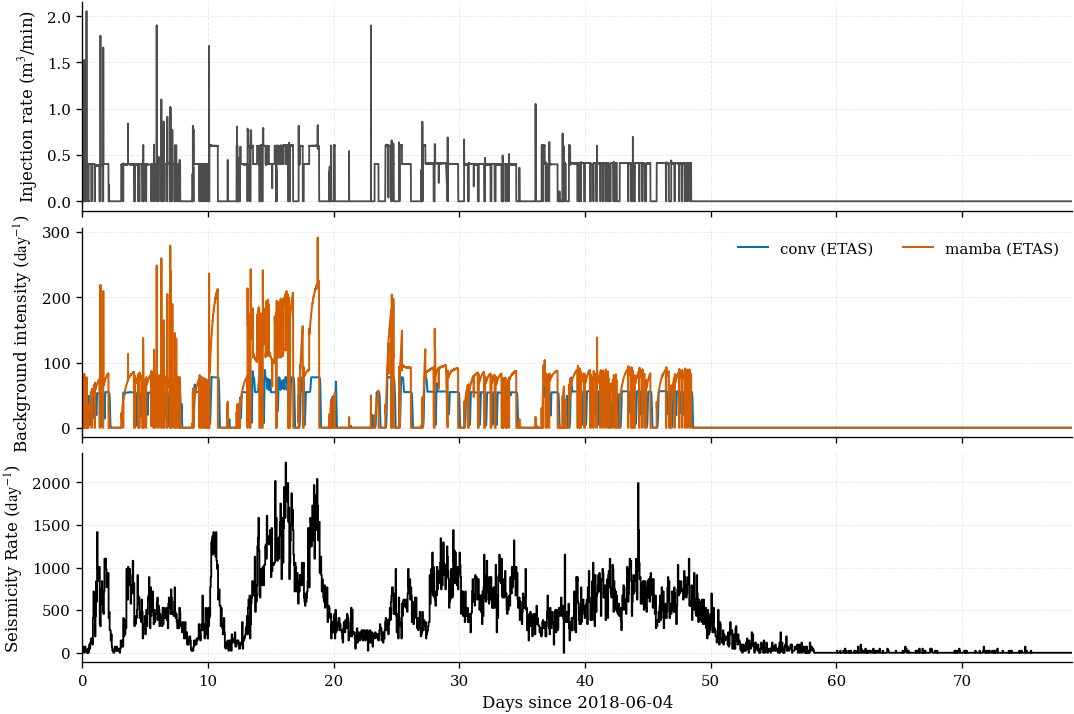

In [10]:
diag_times = batch.time_series_times.reshape(-1)
if diag_times.numel() > 0:
    diag_start = float(diag_times.min().item())
    diag_end = float(diag_times.max().item())
else:
    diag_start = float(seq.t_start)
    diag_end = float(seq.t_end)

if diag_end <= diag_start:
    diag_end = diag_start + 1e-6

injection_color = '#4D4D4D'
model_palette = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#56B4E9', '#E69F00']
model_color_map = {
    name: model_palette[idx % len(model_palette)]
    for idx, name in enumerate(model_registry.keys())
}

def _apply_diag_axis(ax, xlabel=None, ylabel=None, title=None):
    ax.set_xlim(diag_start, diag_end)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title)
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

diag_times_np = batch.time_series_times.squeeze().detach().cpu().numpy()
diag_series_np = batch.time_series.squeeze().detach().cpu().numpy()
date_strs = catalog_ds.metadata['start_ts'].strftime('%Y-%m-%d') if hasattr(catalog_ds.metadata['start_ts'], 'strftime') else 'start'
time_xlabel = 'Days since ' + date_strs

fig, (ax_inj, ax_bg, ax_obs) = plt.subplots(
    3, 1, figsize=(9, 6), sharex=True, constrained_layout=True
)

ax_inj.plot(
    diag_times_np,
    diag_series_np,
    linewidth=1.1,
    color=injection_color,
)
_apply_diag_axis(ax_inj, xlabel='', ylabel=r'Injection rate (m$^3$/min)')

bg_model_count = 0
for idx, (name, rec) in enumerate(model_registry.items()):
    model_i = rec['model']
    if getattr(model_i, 'bg_model', None) is None:
        print(f'[{name}] skipped: no bg_model.')
        continue

    f_intensity_trajectory = model_i.bg_model.intensity_trajectory(batch).reshape(-1)
    ax_bg.plot(
        diag_times_np,
        f_intensity_trajectory.detach().cpu().numpy(),
        linewidth=1.2,
        color=model_color_map.get(name, model_palette[idx % len(model_palette)]),
        label=name,
    )
    bg_model_count += 1

if bg_model_count == 0:
    raise RuntimeError('No model with bg_model was found in model_registry.')

_apply_diag_axis(ax_bg, xlabel='', ylabel=r'Background intensity ($\text{day}^{-1}$)')
ax_bg.legend(frameon=False, ncols=2, loc='upper right')

vis.plot_intensity(seq, dt=1 / 24, ax=ax_obs, T0=diag_start, T=diag_end)
_apply_diag_axis(ax_obs, xlabel=time_xlabel, ylabel=r'Seismicity Rate ($\text{day}^{-1}$)')

save_pub_figure(fig, COMPARE_OUTPUT_DIR / 'background_full.png')
plt.show()

## 5) Single-Window Multi-Model Background Comparison

In [11]:
# Forecast window for multi-model background comparison.
T_FORECAST = 50
FORECAST_DURATION = 10


In [12]:
print(f'T_FORECAST: {T_FORECAST} | FORECAST_DURATION: {FORECAST_DURATION}')
print(f'NUM_SAMPLES: {NUM_SAMPLES} | SAMPLES_PER_BATCH: {SAMPLES_PER_BATCH}')

T_FORECAST: 50 | FORECAST_DURATION: 10
NUM_SAMPLES: 1000 | SAMPLES_PER_BATCH: 1000


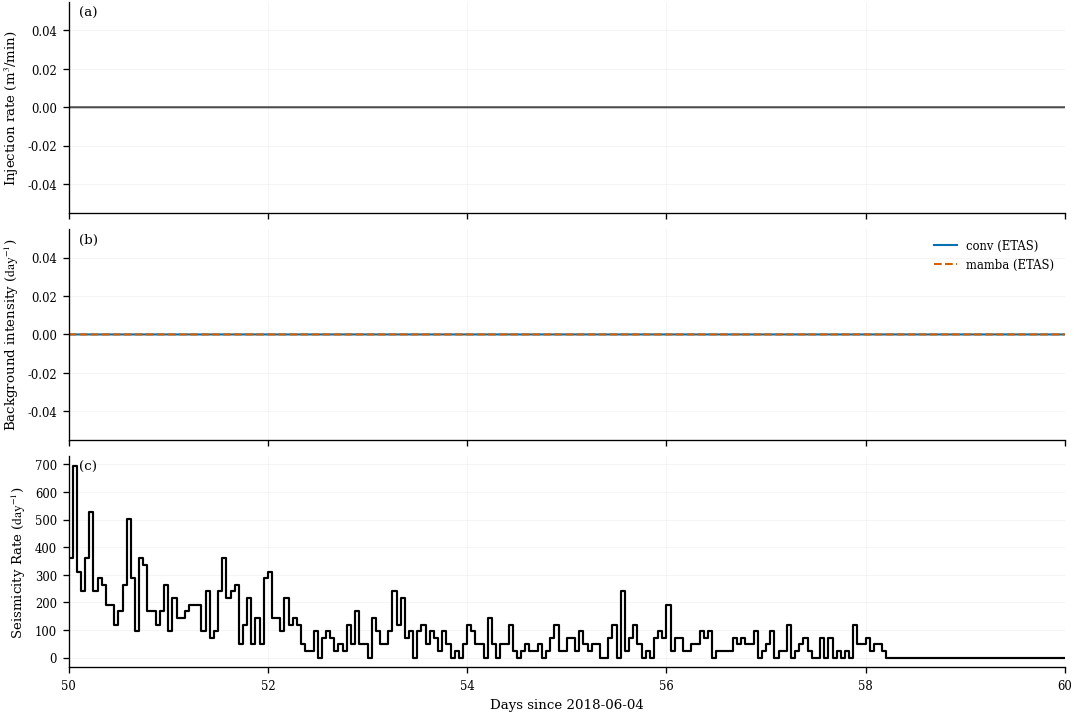

Observed events in window: 826


,model,bg_forecast_count
0,mamba (ETAS),0.000000
1,conv (ETAS),-0.000244


In [13]:
past_seq = seq.get_subsequence(0, T_FORECAST, reset_t_nll_to_end=True)
observed_seq = seq.get_subsequence(T_FORECAST, T_FORECAST + FORECAST_DURATION, reset_t_nll_to_end=True)

window_start = float(T_FORECAST)
window_end = float(T_FORECAST + FORECAST_DURATION)

mask_future = (seq.time_series_times >= window_start) & (seq.time_series_times < window_end)
future_time_series = seq.time_series[mask_future]
future_time_series_times = seq.time_series_times[mask_future]

times_all = seq.time_series_times
window_mask = (times_all >= window_start) & (times_all < window_end)
window_times = times_all[window_mask]
if window_times.numel() == 0:
    raise ValueError(f'No time_series_times points in window [{window_start}, {window_end}).')

window_times_np = window_times.detach().cpu().numpy()
future_times_np = future_time_series_times.detach().cpu().numpy()
future_series_np = future_time_series.reshape(-1).detach().cpu().numpy()

bg_count_records = []
bg_plot_records = []
for name, rec in model_registry.items():
    model_i = rec['model']
    bg_model = getattr(model_i, 'bg_model', None)
    if bg_model is None:
        print(f'[{name}] skipped in window comparison: no bg_model.')
        continue

    bg_model.cache_batch(
        time_series=seq.time_series.unsqueeze(0),
        time_series_times=seq.time_series_times.unsqueeze(0),
    )
    f_intensity = bg_model.intensity(
        ts_batch=bg_model.ts_batch_cache,
        t_query=window_times.unsqueeze(0),
    ).reshape(-1)
    f_intensity_np = f_intensity.detach().cpu().numpy()

    bg_plot_records.append({'model': name, 'intensity': f_intensity_np})
    bg_count_value = float(bg_model.forecast_count(window_start, window_end).detach().cpu().item())
    bg_count_records.append({'model': name, 'bg_forecast_count': bg_count_value})

if not bg_count_records:
    raise RuntimeError('No model with bg_model was available for window comparison.')

bg_matrix = np.vstack([row['intensity'] for row in bg_plot_records]) if bg_plot_records else np.empty((0, window_times_np.size))
inj_max = float(np.nanmax(np.abs(future_series_np))) if future_series_np.size else 0.0
bg_max = float(np.nanmax(np.abs(bg_matrix))) if bg_matrix.size else 0.0
inj_eps = max(1e-8, inj_max * 1e-3)
bg_eps = max(1e-8, bg_max * 1e-3)

activity_mask = np.zeros(window_times_np.shape, dtype=bool)
if future_times_np.size and future_series_np.size:
    inj_on_window = np.interp(window_times_np, future_times_np, future_series_np, left=0.0, right=0.0)
    activity_mask |= np.abs(inj_on_window) > inj_eps
if bg_matrix.size:
    activity_mask |= np.max(np.abs(bg_matrix), axis=0) > bg_eps

if np.any(activity_mask):
    last_active_idx = int(np.where(activity_mask)[0][-1])
    active_end = float(window_times_np[last_active_idx])
    focus_pad = max(0.15, 0.05 * (window_end - window_start))
    display_end = min(window_end, active_end + focus_pad)
else:
    display_end = window_end
display_start = window_start
if display_end <= display_start:
    display_end = display_start + max(0.5, 0.1 * (window_end - window_start))

paper_rc = {
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Nimbus Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'lines.linewidth': 1.3,
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
}

date_strs = catalog_ds.metadata['start_ts'].strftime('%Y-%m-%d') if hasattr(catalog_ds.metadata['start_ts'], 'strftime') else 'start'
time_xlabel = 'Days since ' + date_strs

with plt.rc_context(paper_rc):
    fig, (ax_inj, ax_bg, ax_obs) = plt.subplots(
        3, 1, figsize=(9, 6), sharex=True, constrained_layout=True
    )
    fig.patch.set_facecolor('white')
    injection_color = '#4D4D4D'
    model_palette = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#56B4E9', '#E69F00']
    model_color_map = {
        row['model']: model_palette[idx % len(model_palette)]
        for idx, row in enumerate(bg_plot_records)
    }

    def _apply_window_axis(ax, ylabel=None, title=None, show_xlabel=False):
        ax.set_xlim(display_start, display_end)
        if show_xlabel:
            ax.set_xlabel(time_xlabel)
        if ylabel is not None:
            ax.set_ylabel(ylabel)
        if title is not None:
            ax.set_title(title)
        ax.grid(True, alpha=0.18, linestyle='-', linewidth=0.45, color='#B8B8B8')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    def _add_panel_label(ax, label):
        ax.text(
            0.01,
            0.98,
            label,
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='normal',
        )

    ax_inj.plot(
        future_times_np,
        future_series_np,
        color=injection_color,
        linewidth=1.25,
    )
    _apply_window_axis(
        ax_inj,
        ylabel=r'Injection rate (m$^3$/min)'
    )
    _add_panel_label(ax_inj, '(a)')

    line_styles = ['-', '--', ':', '-.']
    for idx, row in enumerate(bg_plot_records):
        ax_bg.plot(
            window_times_np,
            row['intensity'],
            color=model_color_map.get(row['model'], model_palette[idx % len(model_palette)]),
            linestyle=line_styles[idx % len(line_styles)],
            linewidth=1.25,
            label=row['model'],
        )
    _apply_window_axis(
        ax_bg,
        ylabel=r'Background intensity ($\text{day}^{-1}$)',
    )
    _add_panel_label(ax_bg, '(b)')
    ax_bg.legend(
        frameon=False,
        ncols=1,
        loc='upper right',
    )

    vis.plot_intensity(
        observed_seq,
        dt=1 / 24,
        ax=ax_obs,
        T0=window_start,
        T=window_end,
    )
    _apply_window_axis(
        ax_obs,
        ylabel=r'Seismicity Rate ($\text{day}^{-1}$)',
        show_xlabel=True,
    )
    _add_panel_label(ax_obs, '(c)')

    output_base = COMPARE_OUTPUT_DIR / 'single_window_multi_model_bg_comparison'
    save_pub_figure(fig, output_base, file_format='pdf')
    save_pub_figure(fig, output_base, file_format='png')
    fig.savefig(output_base.with_suffix('.svg'), format='svg', bbox_inches='tight')
    plt.show()

bg_count_df = pd.DataFrame(bg_count_records).sort_values('bg_forecast_count', ascending=False).reset_index(drop=True)
print('Observed events in window:', len(observed_seq))
bg_count_df

In [14]:
import importlib
importlib.reload(vis)

<module 'src.utils.viz_sequences' from '/root/autodl-tmp/em_eqf/src/utils/viz_sequences.py'>

  0%|          | 0/1000 [00:00<?, ?it/s]

[conv (ETAS)] Total forecasts: 1000
[conv (ETAS)] Forecasts containing zero inter_times: 0


  0%|          | 0/1000 [00:00<?, ?it/s]

[mamba (ETAS)] Total forecasts: 1000
[mamba (ETAS)] Forecasts containing zero inter_times: 0


(<Figure size 1500x600 with 6 Axes>,
 {'conv (ETAS)': (<Axes: title={'center': 'Observed Sequence and Example Forecast Trajectories'}, ylabel='Magnitude'>,
   <Axes: title={'center': 'Forecast counts'}, ylabel='Event count in window'>,
   <Axes: ylabel='Cumulative count'>),
  'mamba (ETAS)': (<Axes: xlabel='Days since 2018-06-04', ylabel='Magnitude'>,
   <Axes: xlabel='Frequency', ylabel='Event count in window'>,
   <Axes: ylabel='Cumulative count'>)})

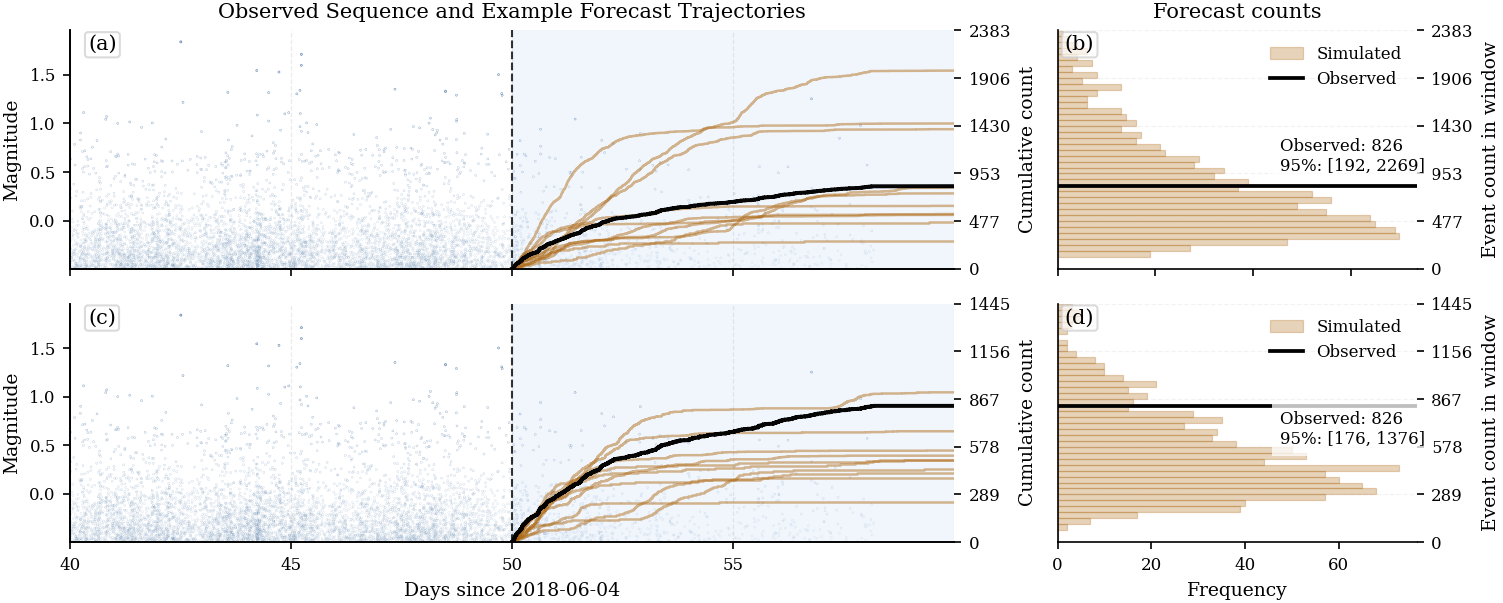

In [15]:
# ...existing code...
def generate_forecasts(model, past_seq, duration, num_samples, samples_per_batch, seed=3):
    return sample_tpp_forecasts(
        model,
        past_seq,
        duration=duration,
        num_samples=int(num_samples),
        samples_per_batch=samples_per_batch,
        seed=seed,
    )

past_seq_device = past_seq.to(DEVICE) if torch.cuda.is_available() else past_seq

all_forecasts_by_model = {}
zero_indices_by_model = {}

for name, rec in model_registry.items():
    forecasts_i = generate_forecasts(
        model=rec["model"],
        past_seq=past_seq_device,
        duration=FORECAST_DURATION,
        num_samples=NUM_SAMPLES,
        samples_per_batch=SAMPLES_PER_BATCH,
        seed=3,
    )
    all_forecasts_by_model[name] = forecasts_i

    zero_indices_i = []
    for idx, fc in enumerate(forecasts_i):
        inter_times = torch.as_tensor(fc.inter_times).cpu()
        if (inter_times == 0).any():
            zero_indices_i.append(idx)
    zero_indices_by_model[name] = zero_indices_i

    print(f"[{name}] Total forecasts: {len(forecasts_i)}")
    print(f"[{name}] Forecasts containing zero inter_times: {len(zero_indices_i)}")

all_forecasts = all_forecasts_by_model[PRIMARY_MODEL_NAME]

date_strs = catalog_ds.metadata["start_ts"].strftime("%Y-%m-%d") if hasattr(catalog_ds.metadata["start_ts"], "strftime") else "start"
vis.visualize_trajectories_multi_model(
    seq,
    all_forecasts_by_model,  
    save_path=COMPARE_OUTPUT_DIR / "all_forecasts_multi_model_vertical.pdf",
    figsize=(10, 2 * len(all_forecasts_by_model)),
    xlabel="Days since " + date_strs,
    reset_t_nll_to_end=True,
)

## 6) RMSE, N-Test, and M-Test

Empty forecasts: 0
Forecast mag range (non-empty only): (3.0331827588520284, -0.4999996430586927)
Observed mag range: (1.2534425258636475, -0.4957028031349182)


PosixPath('/root/autodl-tmp/em_eqf/checkpoints/etas_20260407-122517/m_test.pdf')

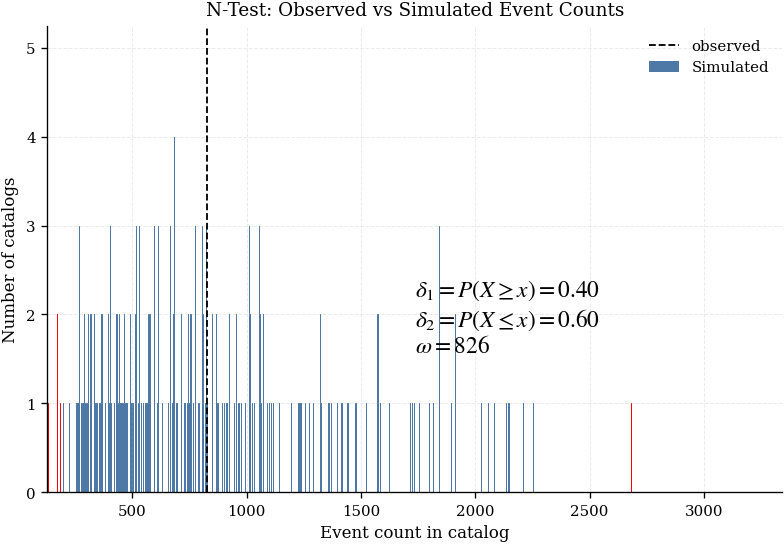

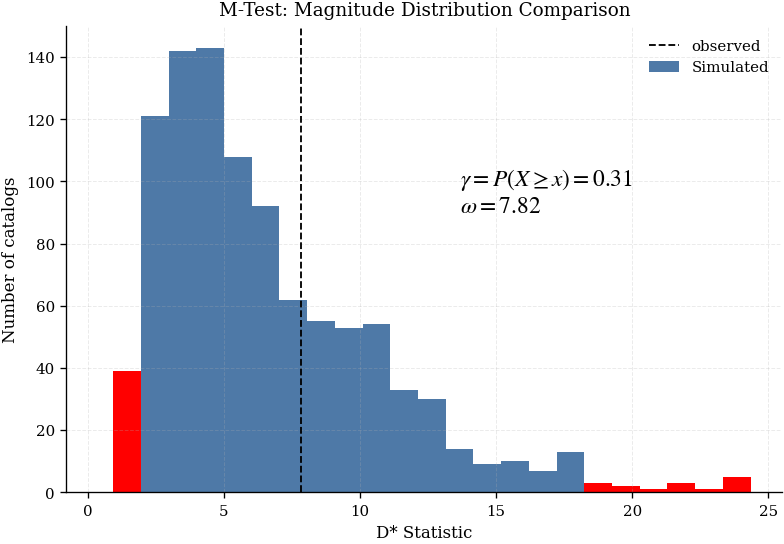

In [16]:
forecast_counts = np.array([len(fc) for fc in all_forecasts], dtype=float)
observed_count = len(observed_seq)
# rmse = float(np.sqrt(np.mean((forecast_counts - observed_count) ** 2)))
# print(f'RMSE: {rmse:.6f}')

number_test_result = catalog_tests.run_number_test_result(
    event_counts=[len(fc) for fc in all_forecasts],
    obs_count=observed_count,
    min_mw=catalog_ds.metadata['mag_completeness'],
    obs_name='observed',
    sim_name='Simulated',
    plot=False,
 )
number_test_result.plot(plot_args={'figsize': (6.8, 4.8), 'tight_layout': False})
fig_n = style_current_figure(title='N-Test: Observed vs Simulated Event Counts')
save_pub_figure(fig_n, CHECKPOINT_DIR / 'n_test.pdf')

non_empty_forecasts = [fc for fc in all_forecasts if len(fc) > 0]
empty_forecast_count = len(all_forecasts) - len(non_empty_forecasts)
print('Empty forecasts:', empty_forecast_count)

if non_empty_forecasts:
    mag_max = [fc.mag.max().item() for fc in non_empty_forecasts]
    mag_min = [fc.mag.min().item() for fc in non_empty_forecasts]
    print('Forecast mag range (non-empty only):', (max(mag_max), min(mag_min)))
else:
    print('Forecast mag range: no non-empty forecasts')

if len(observed_seq) > 0:
    print('Observed mag range:', (observed_seq.mag.max().item(), observed_seq.mag.min().item()))
else:
    print('Observed mag range: observed sequence is empty')

config_dict = {
    'min_mw': catalog_ds.metadata['mag_completeness'],
    'max_mw': 5,
    'dmw': 0.01,
}

if non_empty_forecasts:
    # quick check distribution API on one non-empty forecast
    _ = catalog_tests.compute_magnitude_distribution(non_empty_forecasts[0].mag.cpu().numpy(), **config_dict)

get_counts = functools.partial(catalog_tests.compute_magnitude_distribution, **config_dict)
result_dict = catalog_tests.magnitude_test_from_counts(
    observed_catalog=observed_seq,
    forecast_catalogs=all_forecasts,
    get_counts=lambda cat: get_counts(np.asarray(cat.mag.cpu()))[1],
    verbose=False,
    debug=False,
 )

magnitude_test_result = catalog_tests.run_magnitude_test_result(
    result_dict=result_dict,
    obs_catalog_repr='obs',
    obs_name='observed',
    sim_name='Simulated',
    plot=False,
 )
magnitude_test_result.plot(plot_args={'figsize': (6.8, 4.8), 'tight_layout': False})
fig_m = style_current_figure(title='M-Test: Magnitude Distribution Comparison')
save_pub_figure(fig_m, CHECKPOINT_DIR / 'm_test.pdf')

## 7) Sliding-Window Forecast Evaluation

In [17]:
# Sliding-window settings
SLIDING_DURATION = 2
SLIDING_STEP = 2
SLIDING_QUANTILES = (2.5, 97.5)
RUN_SLIDING_WINDOW_FORECAST = False  # set to True to run the sliding window forecast, which can be time-consuming depending on settings
SLIDING_VIEW_MODE = 'zoomed'  # 'zoomed' | 'full' | 'auto'

# Cache settings: save/load sim_count_matrix and related arrays under checkpoint_dir.
SLIDING_LOAD_CACHE = True
SLIDING_FORCE_RECOMPUTE = False
SLIDING_CACHE_FILENAME = f"sliding_window_cache_{PRIMARY_MODEL_NAME}.npz"


In [18]:
PLOT_COLORS = {
    'true': '#1f77b4',
    'mean': '#ff7f0e',
    'pi': '#4c78a8',
    'err': '#d62728',
    'covered': '#2ca02c',
    'below': '#e45756',
    'above': '#9467bd',
}

if RUN_SLIDING_WINDOW_FORECAST:
    sliding_result = evaluate_sliding_window_forecast_plots(
        model=model,
        seq=seq,
        device=DEVICE,
        catalog_ds=catalog_ds,
        checkpoint_dir=CHECKPOINT_DIR,
        sliding_duration=SLIDING_DURATION,
        sliding_step=SLIDING_STEP,
        sliding_quantiles=SLIDING_QUANTILES,
        samples_per_batch=SAMPLES_PER_BATCH,
        sliding_view_mode=SLIDING_VIEW_MODE,
        load_sliding_cache=SLIDING_LOAD_CACHE,
        force_recompute_sliding=SLIDING_FORCE_RECOMPUTE,
        sliding_cache_filename=SLIDING_CACHE_FILENAME,
        plot_colors=PLOT_COLORS,
    )

    print(f"Sliding cache path: {sliding_result.get('sliding_cache_path', 'N/A')}")
    print(f"Loaded from cache: {bool(sliding_result.get('sliding_loaded_from_cache', False))}")

    if sliding_result.get('status') == 'empty':
        print(sliding_result['message'])
    else:
        t_forecast_list = sliding_result['t_forecast_list']
        counts_list = sliding_result['counts_list']
        q_list = sliding_result['q_list']
        mean_list = sliding_result['mean_list']
        print(f"acceptance rate: {sliding_result['coverage']:.2%}")
        lp_nb = sliding_result.get('lp_nb')
        crps = sliding_result.get('crps')
        w95 = sliding_result.get('w95')
        lp_nb_display = 'N/A' if lp_nb is None or not np.isfinite(lp_nb) else f"{lp_nb:.4f}"
        crps_display = 'N/A' if crps is None or not np.isfinite(crps) else f"{crps:.4f}"
        print(
            f"MAE: {sliding_result['mae']:.4f} | RMSE: {sliding_result['rmse']:.4f} | CRPS: {crps_display} | LP_NB: {lp_nb_display} | W95: {w95:.4f}"
        )


In [19]:
import numpy as np

model.eval()
grid_device = getattr(model, 'device', DEVICE)
test_grid = torch.linspace(0, 1, 200, device=grid_device)

pred_dist = None
if hasattr(model, 'bg_model') and hasattr(model.bg_model, 'svgp'):
    with torch.no_grad():
        pred_dist = model.bg_model.svgp(test_grid.unsqueeze(-1))
elif hasattr(model, 'bg_model') and hasattr(model.bg_model, 'gp_model'):
    try:
        with torch.no_grad():
            pred_dist = model.bg_model.gp_model(test_grid.unsqueeze(-1))
    except Exception as exc:
        print(f'Skip latent GP plot: unable to query gp_model ({exc}).')
else:
    print("Skip latent GP plot: bg_model has no 'svgp' or 'gp_model' interface.")

if pred_dist is not None:
    mean = pred_dist.mean.detach().cpu().numpy()
    var = pred_dist.variance.detach().cpu().numpy()
    std = np.sqrt(var)

    latent_idx = 0
    x = test_grid.detach().cpu().numpy().reshape(-1)
    if mean.ndim == 2:
        y = mean[:, latent_idx]
        y_std = std[:, latent_idx]
    else:
        y = mean.reshape(-1)
        y_std = std.reshape(-1)

    fig, ax = plt.subplots(figsize=(8.8, 4.4))
    ax.plot(
        x,
        y,
        color='#1f77b4',
        linewidth=1.2,
        label=f'Latent Mean (dim={latent_idx})',
    )
    ax.fill_between(
        x,
        y - 2 * y_std,
        y + 2 * y_std,
        alpha=0.18,
        color='#4c78a8',
        label='+- 2 StdDev',
    )
    ax.set_xlabel('Normalized Time')
    ax.set_ylabel('Latent Value')
    ax.set_title('Latent Background Process Posterior')
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False)
    fig.tight_layout()
    save_pub_figure(fig, CHECKPOINT_DIR / 'latent_background_posterior.png')
    plt.show()


Skip latent GP plot: bg_model has no 'svgp' or 'gp_model' interface.
